Importações necessárias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive, AutoETS
from fpppy.utils import plot_series

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

from pyFTS.partitioners import Grid
from pyFTS.models import chen, pwfts
from pyFTS.benchmarks import ResidualAnalysis as ra
from pyFTS.benchmarks import Measures

Iremos usar o mesmo arquivo que foi treinado a Regressão Linear a fins de comparação

In [2]:
st = pd.read_csv('./Sandbox_Reg_Lin/Staging Area/porto_ts.csv')

st['data'] = st['ano'].astype(str) + '-' + st['mes'].astype(str).str.zfill(2) + '-01' #faz uma coluna com ano-mes-dia juntando colunas ano e mes que estavam separadas

st['data'] = pd.to_datetime(st['data'])
st = st.set_index('data')
display(st)

,ano,mes,porto,graos,outras,sugar
data,,,,,,
2005-01-01,2005,1,5027941,412400,1780376,581383
2005-02-01,2005,2,5316605,707274,1821686,878016
2005-03-01,2005,3,5899912,1221079,1917759,610140
2005-04-01,2005,4,5850639,1301598,1976311,764285
2005-05-01,2005,5,6826372,1575474,2122232,1007705
...,...,...,...,...,...,...
2022-08-01,2022,8,14626790,4122517,3188229,2455597
2022-09-01,2022,9,13628567,3743920,3258989,2079487
2022-10-01,2022,10,14435751,4185655,3198681,2249483


Vamos utilizar o recorte dos dados do período que vai ser previsto.

In [3]:
real_st = pd.read_csv('../data/processed/real_st.csv')
real_st['data'] = pd.to_datetime(real_st['data'])
real_st = real_st.set_index('data')
display(real_st.head(10))

,porto
data,
2023-01-01,1.026399e+07
2023-02-01,1.098402e+07
2023-03-01,1.533587e+07
2023-04-01,1.373355e+07
2023-05-01,1.514737e+07
2023-06-01,1.560657e+07
2023-07-01,1.535087e+07
2023-08-01,1.515960e+07
2023-09-01,1.621269e+07


E por último vamos puxar os dados da Regressão Linear

In [4]:
model_lin_reg = pd.read_csv('../data/external/predict_RL.csv', parse_dates=['data'], index_col = 0)
model_lin_reg['data'] = pd.to_datetime(model_lin_reg['data'])
model_lin_reg = model_lin_reg.set_index('data')
display(model_lin_reg.head(10))

,porto
data,
2023-01-01,9992517
2023-02-01,11986607
2023-03-01,14826853
2023-04-01,13829706
2023-05-01,13908953
2023-06-01,13456205
2023-07-01,14314263
2023-08-01,14296738
2023-09-01,13499045


In [5]:
def plot_diagnostics(data):
    _, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
    ax = axes["resid"]
    ax.plot(data["ds"], data["resid"])
    ax.set(title="Innovation Residuals")
    ax = axes["acf"]
    plot_acf(data["resid"].dropna(),
        zero=False, bartlett_confint=False, auto_ylims=True, ax=ax)
    ax.set(title="ACF Plot", xlabel="lag[1]", ylabel="acf")
    ax = axes["hist"]
    ax.hist(data["resid"], bins=20)
    ax.set(title="Histogram", xlabel="resid", ylabel="count")

plt.rcParams["figure.figsize"] = (16, 8)

# Modelos Clássicos

Nessa seção traremos 2 modelos da estatística clássica que servirão de demonstração de nossa tese para os modelos FTS.

Um desses modelos será o Seasonal Naïve dado a característica dessa série ter um padrão repetitivo sazonalidade constante, e o outro será o modelo de suavização exponencial tripla Holt Winters que foi projetado especificamente para uma série dessa com tendência e sazonalidade. Ambos os modelos são "de baixo custo computacional".

Referências:

<small>Hyndman, R.J., Athanasopoulos, G., Garza, A., Challu, C., Mergenthaler, M., & Olivares, K.G. (2025). Forecasting: Principles and Practice, the Pythonic Way.

<small>(5.2 Some simple forecasting methods), (8.3 Methods with seasonality).

In [6]:
# Criando as colunas 'ds', 'y' e 'unique_id' para o StasForecast
df_stats = st.reset_index().copy()
df_stats.drop(columns=['graos','outras','sugar','ano','mes'], inplace = True)
df_stats.columns = ['ds', 'y']
df_stats['unique_id'] = 'porto'
display(df_stats)

,ds,y,unique_id
0,2005-01-01,5027941,porto
1,2005-02-01,5316605,porto
2,2005-03-01,5899912,porto
3,2005-04-01,5850639,porto
4,2005-05-01,6826372,porto
...,...,...,...
211,2022-08-01,14626790,porto
212,2022-09-01,13628567,porto
213,2022-10-01,14435751,porto
214,2022-11-01,12194409,porto


Instanciando o modelo Seasonal Naïve

In [7]:
seasonal_naive_method = SeasonalNaive(12)
model_seasonal_naive = StatsForecast(models=[seasonal_naive_method], freq="MS")

Aplicando e gerando as previões

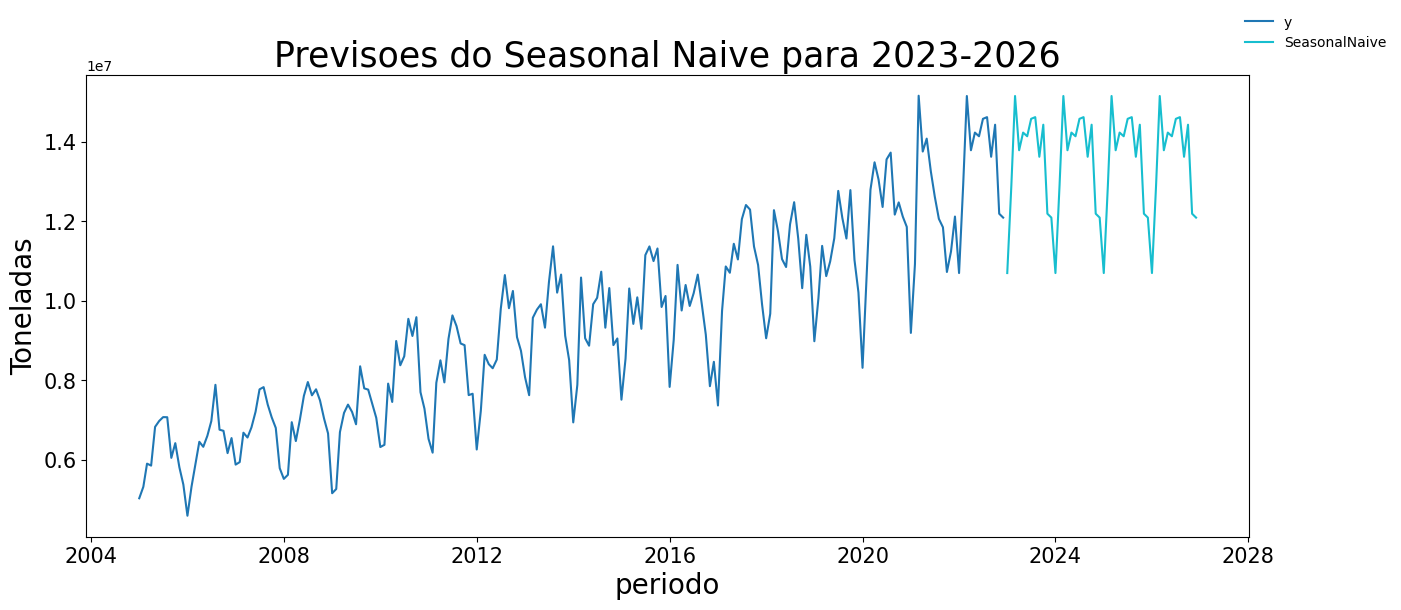

In [8]:
# Re-fitting with fitted=True to allow in-sample residual calculation
model_seasonal_naive.fit(df_stats)
forecast_seasonal_naive = model_seasonal_naive.forecast(df=df_stats, h=48, fitted=True)

# Visualizing the historical data and out-of-sample predictions
plot_series(df_stats, forecast_seasonal_naive,
            xlabel='periodo', ylabel='Toneladas',
            title='Previsoes do Seasonal Naive para 2023-2026',
            rm_legend=False)

In [9]:
display(forecast_seasonal_naive.head(10))

,unique_id,ds,SeasonalNaive
0,porto,2023-01-01,10699935.0
1,porto,2023-02-01,12899826.0
2,porto,2023-03-01,15158804.0
3,porto,2023-04-01,13792995.0
4,porto,2023-05-01,14237454.0
5,porto,2023-06-01,14144789.0
6,porto,2023-07-01,14583718.0
7,porto,2023-08-01,14626790.0
8,porto,2023-09-01,13628567.0
9,porto,2023-10-01,14435751.0


In [10]:
forecast_seasonal_naive['y'] = forecast_seasonal_naive['SeasonalNaive']
forecast_seasonal_naive.drop(columns=['SeasonalNaive'], inplace=True)
display(forecast_seasonal_naive.head(10))

,unique_id,ds,y
0,porto,2023-01-01,10699935.0
1,porto,2023-02-01,12899826.0
2,porto,2023-03-01,15158804.0
3,porto,2023-04-01,13792995.0
4,porto,2023-05-01,14237454.0
5,porto,2023-06-01,14144789.0
6,porto,2023-07-01,14583718.0
7,porto,2023-08-01,14626790.0
8,porto,2023-09-01,13628567.0
9,porto,2023-10-01,14435751.0


Vamos verificar em um gráfico como as previsões do Seasonal Naïve se adequam a realidade dos dados e juntamente verificar com a Regressão Linear.

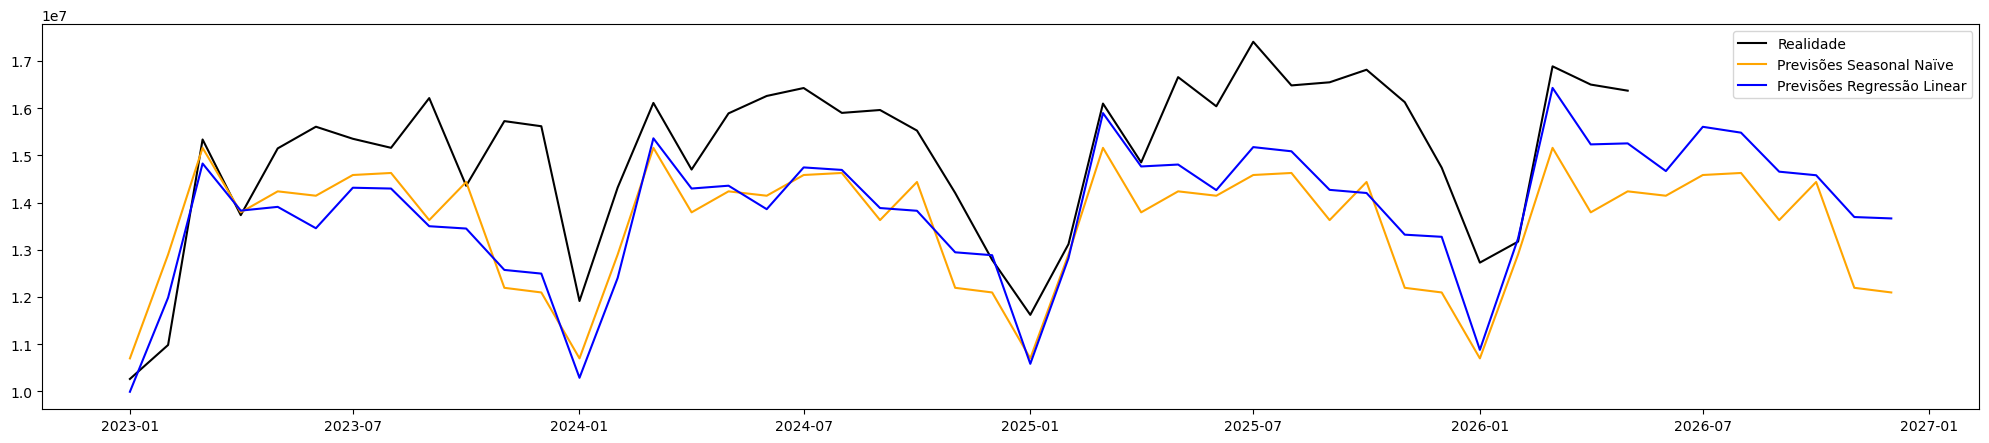

In [11]:
fig, ax = plt.subplots(figsize=[25,5])

ax.plot(real_st.index, real_st['porto'], label='Realidade', color='black')
ax.plot(forecast_seasonal_naive['ds'], forecast_seasonal_naive['y'], label='Previsões Seasonal Naïve', color='orange')
ax.plot(model_lin_reg.index, model_lin_reg['porto'], label='Previsões Regressão Linear', color='blue')
plt.legend()
plt.show()

Auditoria dos resíduos para ver se há autocorrelação:

In [12]:
insample_seasonal_naive = model_seasonal_naive.forecast_fitted_values()

insample_seasonal_naive = insample_seasonal_naive.assign(resid=lambda x: x['y'] - x['SeasonalNaive'])

display(insample_seasonal_naive)

,unique_id,ds,y,SeasonalNaive,resid
0,porto,2005-01-01,5027941.0,NaN,NaN
1,porto,2005-02-01,5316605.0,NaN,NaN
2,porto,2005-03-01,5899912.0,NaN,NaN
3,porto,2005-04-01,5850639.0,NaN,NaN
4,porto,2005-05-01,6826372.0,NaN,NaN
...,...,...,...,...,...
211,porto,2022-08-01,14626790.0,12065858.0,2560932.0
212,porto,2022-09-01,13628567.0,11851872.0,1776695.0
213,porto,2022-10-01,14435751.0,10727403.0,3708348.0
214,porto,2022-11-01,12194409.0,11241892.0,952517.0


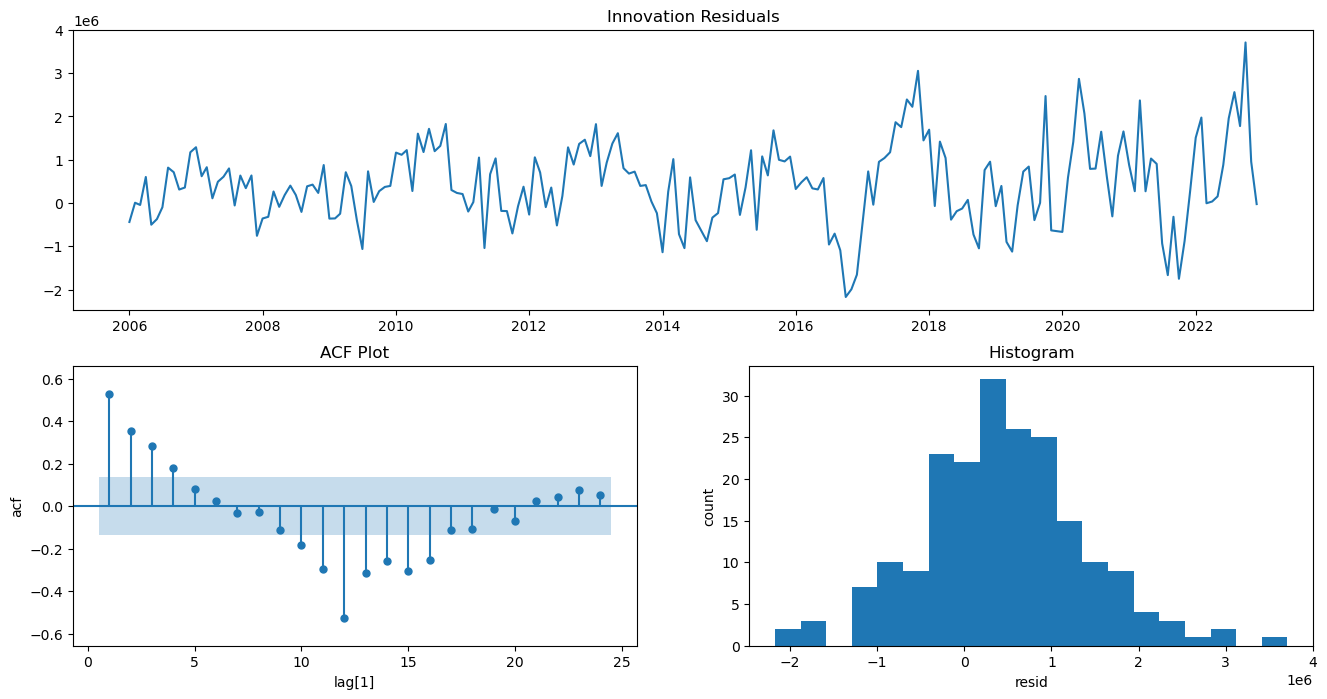

In [13]:
plot_diagnostics(insample_seasonal_naive)

No diagnóstico visual demonstra que os resíduos não tem uma distribuição em torno de 0 e o ACF demonstra uma autocorrelação positiva nos lags 1 e 2 estão fora da zona azul, indicando que apesar do método ter capturado a sazonalidade ele deixou para trás alguma informação.


---


Abaixo formalizaremos através do teste Ljung-Box e Shapiro-Wilk.

Ljung-Box:
Hipótese Nula $ H_0 $: Os dados são independentes e identicamente distribuídos (IID), ou seja, não há autocorrelação.

Hipótese Alternativa $ H_a $: Existe dependência serial (autocorrelação) nos dados.

In [14]:
residuos_limpos = insample_seasonal_naive['resid'].dropna().values #filtrando os resíduos removendo os NaNs

teste_LB = acorr_ljungbox(residuos_limpos, lags=[1, 6, 12], return_df=True)
print(teste_LB.round(4))

     lb_stat  lb_pvalue
1    57.9857        0.0
6   109.1967        0.0
12  199.1589        0.0


Nos lags 1, 2 e 3 conforme vimos no plot acima estão fora do intervalo de confiança e pelo resultado do $ p-valor = 0 < 0.05 $ rejeitamos a hipótese nula.


---


Abaixo veremos o teste de Shapiro-Wilk que testará:

Hipótese Nula $ H_0 $: Os dados seguem uma distribuição normal.

Hipótese Alternativa $ H_1 $: Os dados não seguem uma distribuição normal.

In [15]:
t_stat, p_valor = stats.ttest_1samp(residuos_limpos, popmean=0)
print(f"t = {t_stat:.4f}, p = {p_valor:.4f}")

t = 6.6552, p = 0.0000


resultado do $ p-valor = 0 < 0.05 $ rejeitamos a hipótese nula.

Isso confirma o que vimos no plot de disgnóstico dos resíduos acima.


---

Próximo passo é aplicar o modelo paramétrico que idealmente seria o adequado para esse tipo de série com tendência e sazonalidade: Holt Winters de suavização exponencial tripla.

In [16]:
display(df_stats)

,ds,y,unique_id
0,2005-01-01,5027941,porto
1,2005-02-01,5316605,porto
2,2005-03-01,5899912,porto
3,2005-04-01,5850639,porto
4,2005-05-01,6826372,porto
...,...,...,...
211,2022-08-01,14626790,porto
212,2022-09-01,13628567,porto
213,2022-10-01,14435751,porto
214,2022-11-01,12194409,porto


In [17]:
print(df_stats.dtypes)

ds           datetime64[ns]
y                     int64
unique_id            object
dtype: object


Há 2 variações desse modelo HW, multiplicativo e aditivo, nós aplicaremos ambas apesar de previamente sabermos que o correto seria o Holt Winters aditivo dado as características que vimos na EDA.

Instanciando os modelos e gerando as previsões:

In [18]:
holt_winters_models = StatsForecast(
    models=[
        AutoETS(season_length=12, model="AAA", alias="additive"),
        AutoETS(season_length=12, model="MAM", alias="multiplicative"),
    ],
    freq="MS",
)
holt_winters_forecasts = holt_winters_models.forecast(df=df_stats, h=48, fitted=True)

In [19]:
display(holt_winters_forecasts.head(10))

,unique_id,ds,additive,multiplicative
0,porto,2023-01-01,10760847.0,10371137.0
1,porto,2023-02-01,11991189.0,11399990.0
2,porto,2023-03-01,13719839.0,13809239.0
3,porto,2023-04-01,12878750.0,13345690.0
4,porto,2023-05-01,13049610.0,13760556.0
5,porto,2023-06-01,12931872.0,13731603.0
6,porto,2023-07-01,13605422.0,14581860.0
7,porto,2023-08-01,13824114.0,15085746.0
8,porto,2023-09-01,13146628.0,14040411.0
9,porto,2023-10-01,13184148.0,14117378.0


Vamos plotar os resultados de ambos para verificar como geram as previões:

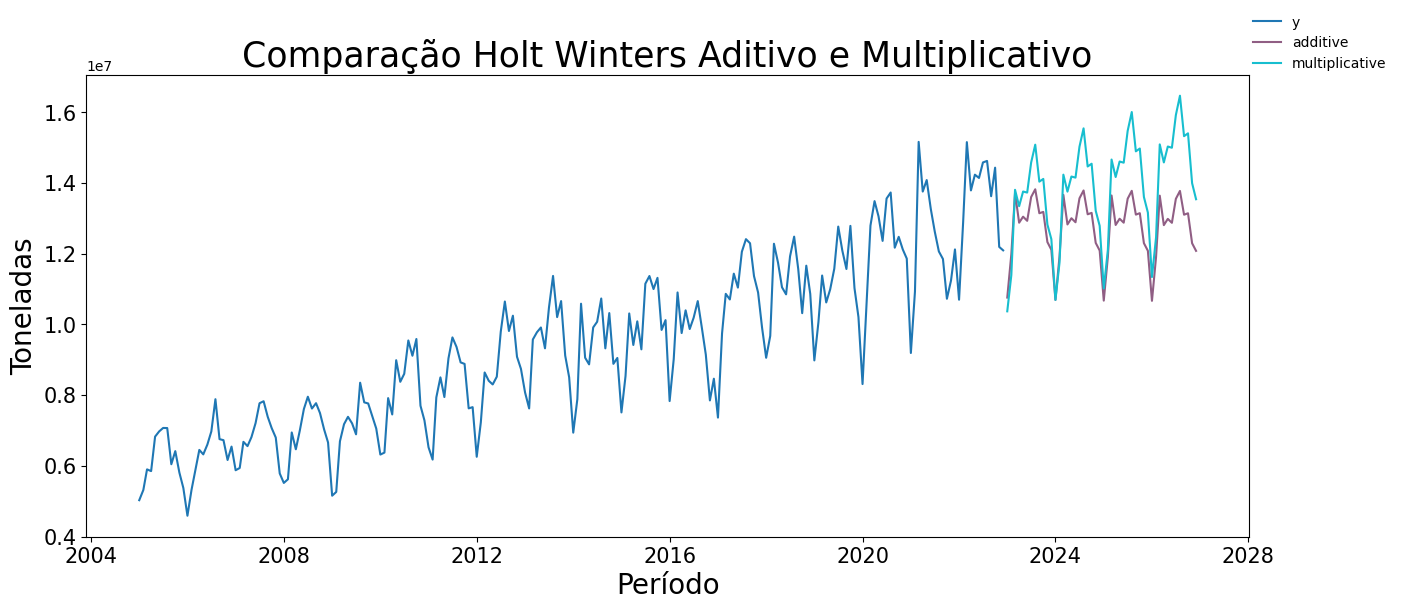

In [20]:
plot_series(df_stats,
            holt_winters_forecasts[['unique_id', 'ds', 'additive', 'multiplicative']],
            xlabel='Período',
            ylabel='Toneladas',
            title='Comparação Holt Winters Aditivo e Multiplicativo',
            rm_legend=False)

Claramente observável que o HW multiplicativo apresenta valores bem acima do HW aditivo, porém precisamos verificar isso em relação aos dados que realmente ocorreram na série:

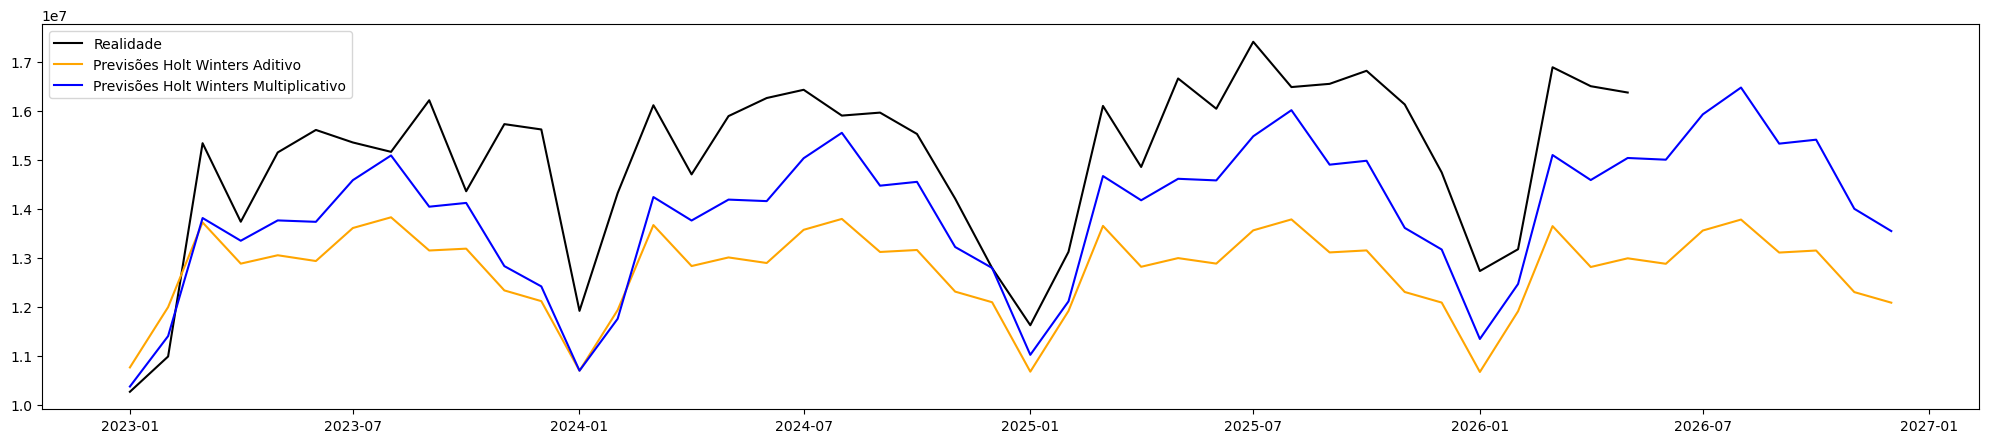

In [21]:
fig, ax = plt.subplots(figsize=[25,5])

ax.plot(real_st.index, real_st['porto'], label='Realidade', color='black')
ax.plot(holt_winters_forecasts['ds'], holt_winters_forecasts['additive'], label='Previsões Holt Winters Aditivo', color='orange')
ax.plot(holt_winters_forecasts['ds'], holt_winters_forecasts['multiplicative'], label='Previsões Holt Winters Multiplicativo', color='blue')
plt.legend()
plt.show()

Aqui já podemos ver que na realidade o modelo HW obteve melhor perfomance preditiva do que o HW aditivo, mas antes de apostarmos em um ou em outro como modelo ideal vamos verificar os resíduos a fim de atestar se os modelos estão bem especidicados.


---

Vamos separar 2 DataFrames distintos para cada modelo:

In [22]:
import pandas as pd

# Retrieve in-sample fitted values for Holt-Winters models
insample_hw = holt_winters_models.forecast_fitted_values()

# Separate into Additive and Multiplicative DataFrames for analysis
holt_winters_forecasts_add = insample_hw[['unique_id', 'ds', 'y', 'additive']].copy()
holt_winters_forecasts_add['resid'] = holt_winters_forecasts_add['y'] - holt_winters_forecasts_add['additive']

holt_winters_forecasts_mult = insample_hw[['unique_id', 'ds', 'y', 'multiplicative']].copy()
holt_winters_forecasts_mult['resid'] = holt_winters_forecasts_mult['y'] - holt_winters_forecasts_mult['multiplicative']

print("Holt-Winters Additive In-Sample Residuals:")
display(holt_winters_forecasts_add.head())

print("Holt-Winters Multiplicative In-Sample Residuals:")
display(holt_winters_forecasts_mult.head())

Holt-Winters Additive In-Sample Residuals:


,unique_id,ds,y,additive,resid
0,porto,2005-01-01,5027941.0,4958331.5,69609.5
1,porto,2005-02-01,5316605.0,5641670.0,-325065.0
2,porto,2005-03-01,5899912.0,6609709.0,-709797.0
3,porto,2005-04-01,5850639.0,5534902.5,315736.5
4,porto,2005-05-01,6826372.0,5967980.0,858392.0


Holt-Winters Multiplicative In-Sample Residuals:


,unique_id,ds,y,multiplicative,resid
0,porto,2005-01-01,5027941.0,4572537.0,455404.0
1,porto,2005-02-01,5316605.0,5054565.5,262039.5
2,porto,2005-03-01,5899912.0,6149758.5,-249846.5
3,porto,2005-04-01,5850639.0,5955180.5,-104541.5
4,porto,2005-05-01,6826372.0,6156066.5,670305.5


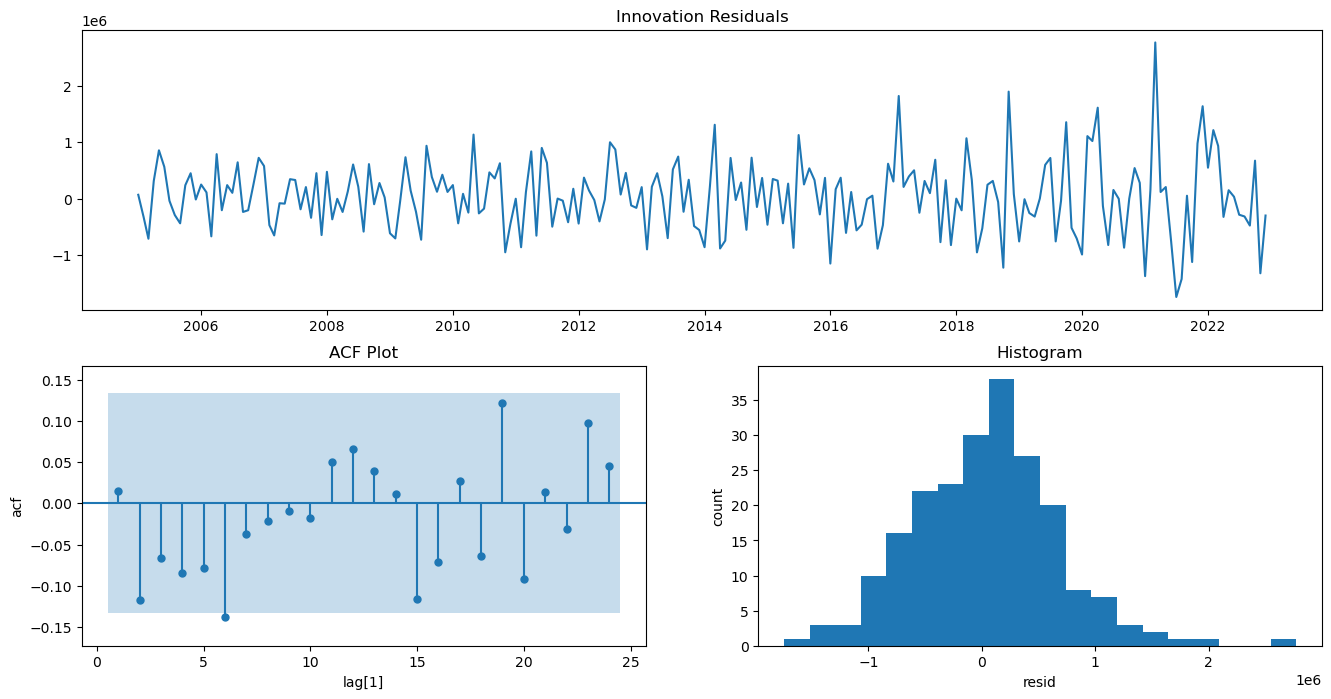

In [23]:
plot_diagnostics(holt_winters_forecasts_add)

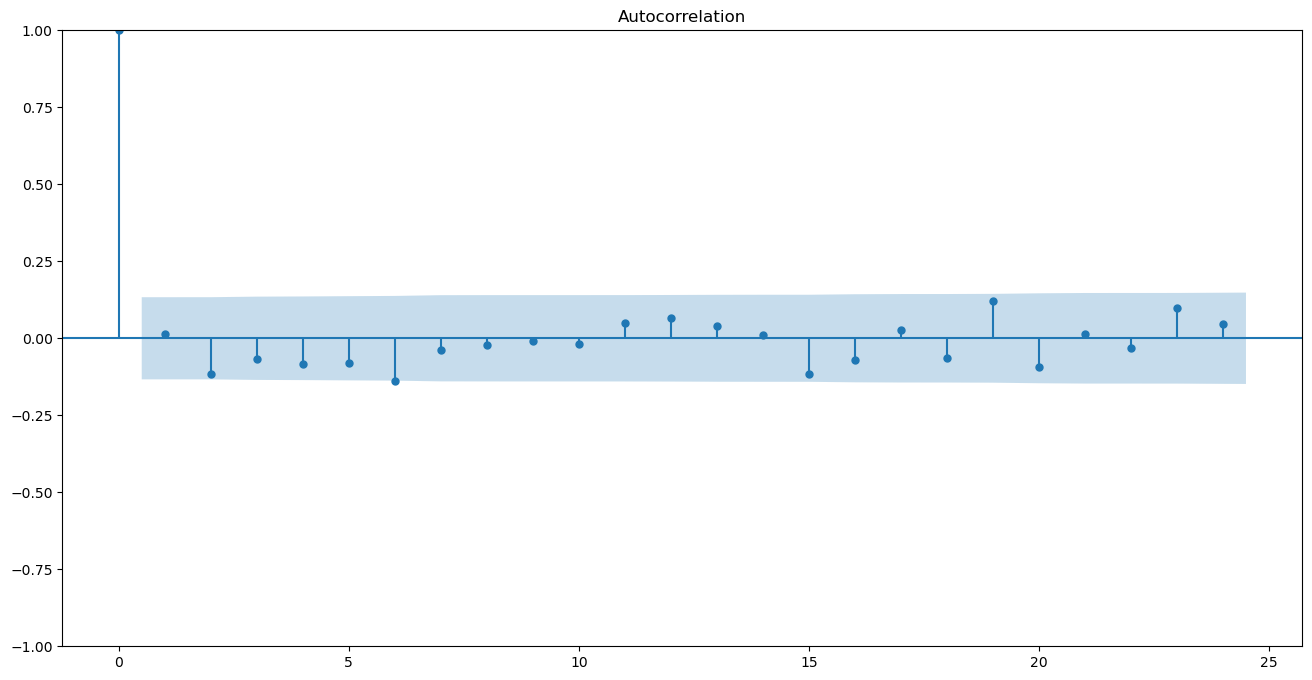

In [24]:
plot_acf(holt_winters_forecasts_add['resid'], lags=24)
plt.show()

In [25]:
residuos_limpos_hw_add = holt_winters_forecasts_add['resid'].dropna().values #filtrando os resíduos removendo os NaNs

teste_LB = acorr_ljungbox(residuos_limpos_hw_add, lags=[1, 6, 12, 24], return_df=True)
print(teste_LB)

      lb_stat  lb_pvalue
1    0.050898   0.821508
6   11.278037   0.080154
12  13.375059   0.342379
24  27.863271   0.265849


In [26]:
t_stat, p_valor = stats.ttest_1samp(residuos_limpos_hw_add, popmean=0)
print(f"t = {t_stat:.4f}, p = {p_valor:.4f}")

t = 1.0425, p = 0.2984


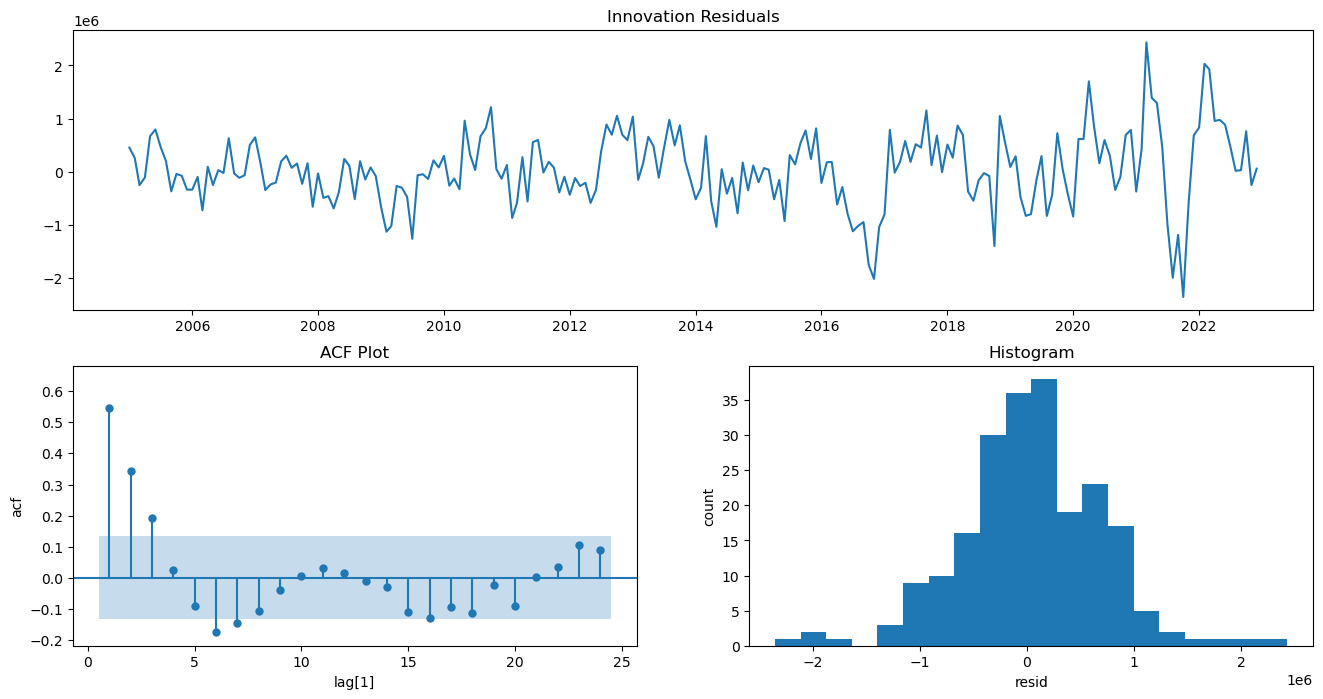

In [27]:
plot_diagnostics(holt_winters_forecasts_mult)

In [28]:
residuos_limpos_hw_mult = holt_winters_forecasts_mult['resid'].dropna().values #filtrando os resíduos removendo os NaNs

teste_LB = acorr_ljungbox(residuos_limpos_hw_mult, lags=[1, 6, 12, 24], return_df=True)
print(teste_LB.round(4))

     lb_stat  lb_pvalue
1    65.0995        0.0
6   108.0707        0.0
12  116.1520        0.0
24  135.4090        0.0


In [29]:
t_stat, p_valor = stats.ttest_1samp(residuos_limpos_hw_mult, popmean=0)
print(f"t = {t_stat:.4f}, p = {p_valor:.4f}")
#

t = 0.8947, p = 0.3719


# Modelos Fuzzy Time Series

Nessa seção partiremos para os modelos de Fuzzy Time Series, aqui veremos 2 tipos de modelos, o clássico Chen (1996) que substituiu o original, de Song e Chissom (1993), por operações aritméticas simples em vez de operações matriciais complexas. E também o modelo de pesos probrabilísticos PWFTS.


---

Vamos começar visualizando a série histórica do porto:

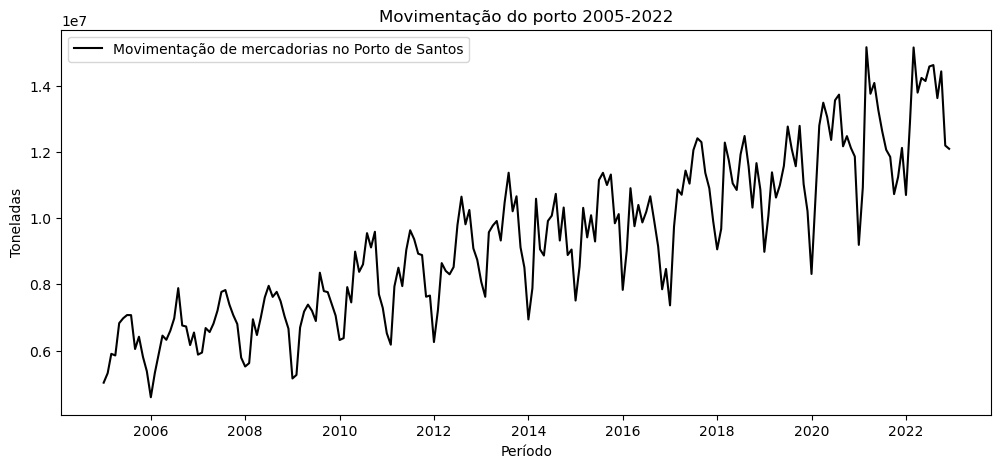

In [30]:
fig, ax = plt.subplots(figsize=[12,5])

ax.plot(st.index, st['porto'], linewidth=1.5, label='Movimentação de mercadorias no Porto de Santos', color='black')

ax.set_title('Movimentação do porto 2005-2022')
ax.set_ylabel('Toneladas')
ax.set_xlabel('Período')

ax.legend()
plt.show()

No modelo de Chen começamos por particionar o Universo de Discurso (UoD) e atribuir valores linguísticos as partições depois nos demais passos devemos ver as relações lógicas fuzzy e criar as relações, mas com a biblioteca pyFTS nós conseguimos aplicar o modelo somente criando o particionador e instanciando o modelo e por fim gerando as previsões bem fácilmente.

/opt/conda/lib/python3.11/site-packages/pyFTS/partitioners/partitioner.py:238: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.xaxis.set_ticklabels(ticks)


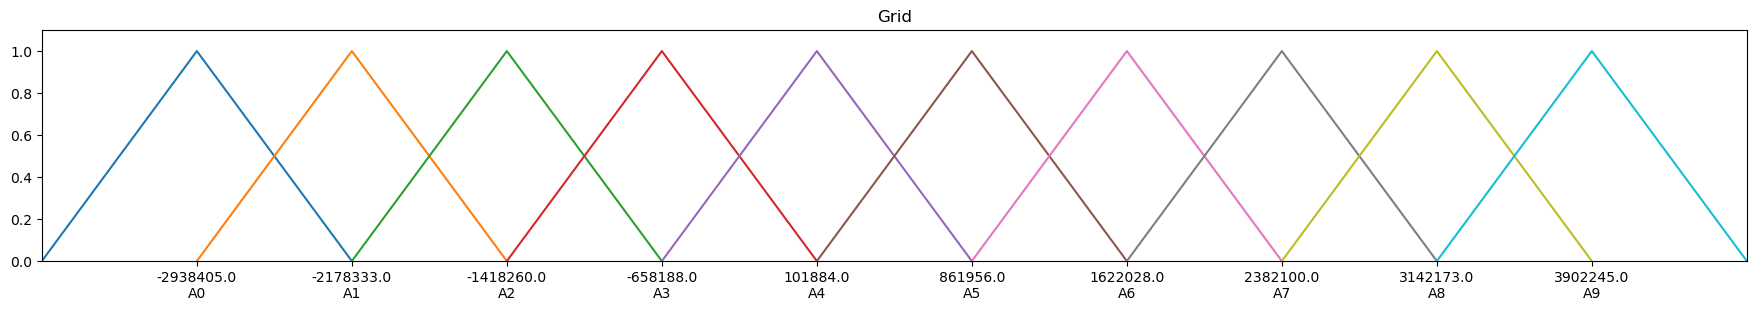

In [31]:
from pyFTS.common import Transformations

port_data = st['porto'].values

diff = Transformations.Differential(1)
data_diff = diff.apply(port_data)

fig, ax = plt.subplots(figsize=[22,3])
part = Grid.GridPartitioner(data=data_diff, npart=10)
part.plot(ax)

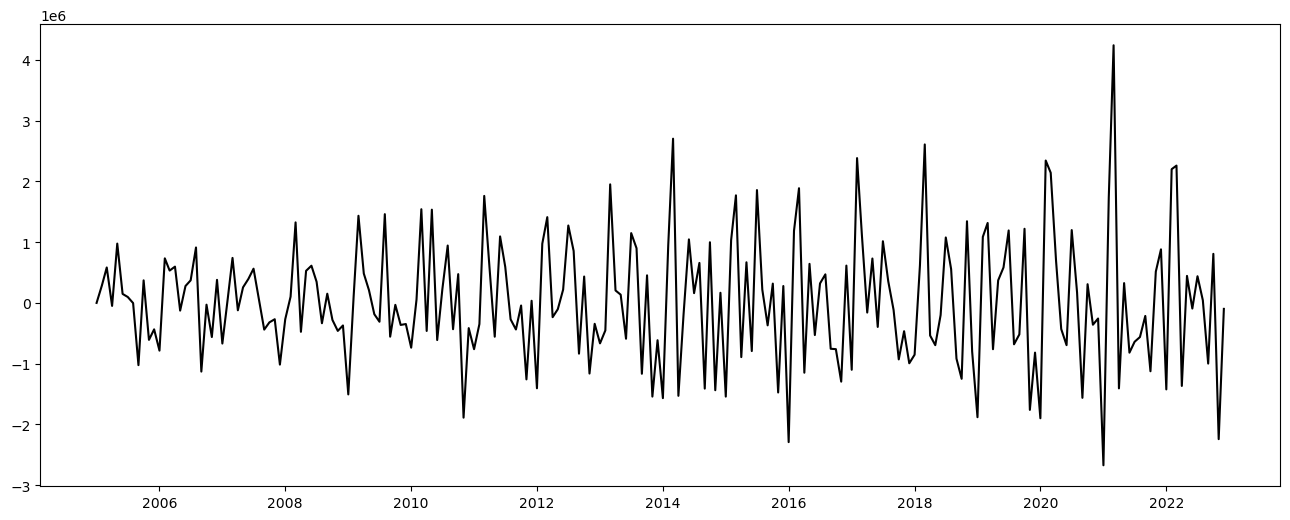

In [32]:
fig, ax = plt.subplots(figsize=[16,6])
ax.plot(st.index, data_diff, color='black')
plt.show()

In [33]:
np.int = np.int64
model = chen.ConventionalFTS(partitioner = part)
model.fit(data_diff)
print(model)

Conventional FTS:
A9 -> A2
A4 -> A0,A1,A2,A3,A4,A5,A6
A3 -> A1,A2,A3,A4,A5,A6
A5 -> A1,A2,A3,A4,A5,A6,A7
A7 -> A2,A3,A5,A7
A6 -> A2,A3,A4,A5,A9
A1 -> A3,A4,A5,A7
A2 -> A3,A4,A5,A6,A7
A0 -> A6



In [34]:
forecast_diff = model.predict(data_diff, steps_ahead=1)
forecast = diff.inverse(forecast_diff, port_data)
print(f'Previsão de FTS: {forecast[-1]}')
print(f'Valor real: {real_st["porto"].iloc[0]}')

Previsão de FTS: 11438081.809999999
Valor real: 10263991.863


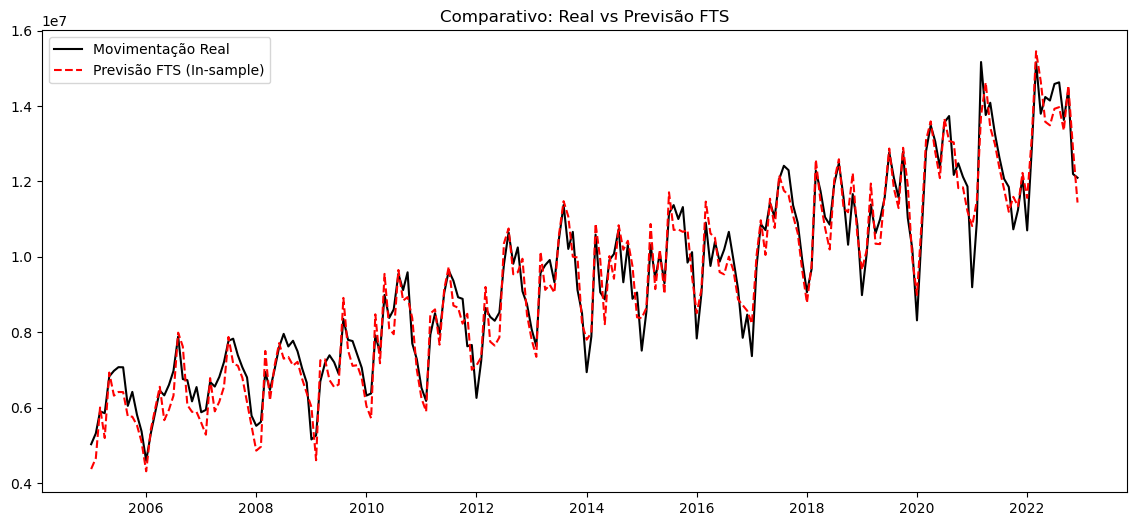

In [35]:
from matplotlib import lines
fig, ax = plt.subplots(figsize=[14, 6])

# Ajustando o índice para bater com o tamanho do forecast (os primeiros 'order' valores não possuem previsão)
idx = st.index[-len(forecast):]

ax.plot(st.index, st['porto'], linewidth=1.5, label='Movimentação Real', color='black')
ax.plot(idx, forecast, linestyle='--', linewidth=1.5, label='Previsão FTS (In-sample)', color='red')

ax.set_title('Comparativo: Real vs Previsão FTS')
ax.legend()
plt.show()

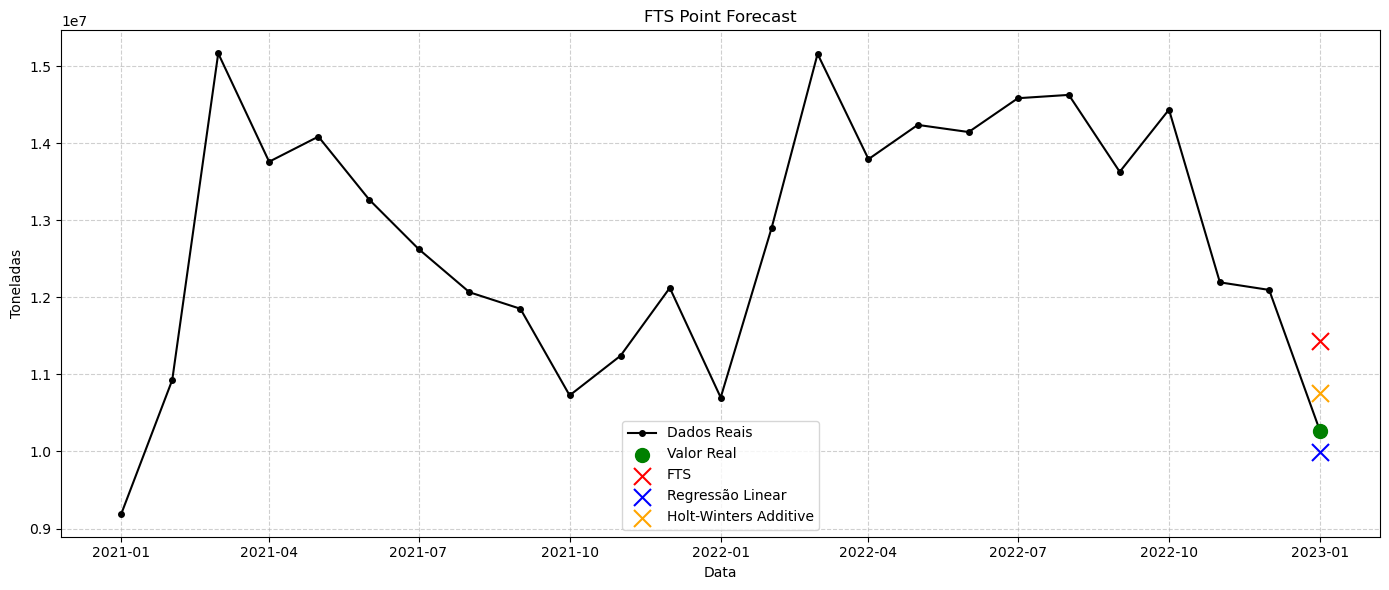

In [36]:
history_series = st['porto'].iloc[-24:]
actual_series = real_st['porto'].iloc[:1]
forecast_val = forecast[-1]
regression_val = model_lin_reg['porto'].iloc[0]
hw_add_val = holt_winters_forecasts['additive'].iloc[0]

# Combine history and actual for a continuous line plot
combined_actual = pd.concat([history_series, actual_series])

plt.figure(figsize=(14, 6))

# Plot the historical line connecting to the real value
plt.plot(combined_actual.index, combined_actual.values, label='Dados Reais', color='black', marker='o', markersize=4)

# Highlight the specific real value point
plt.scatter(actual_series.index, actual_series.values, color='green', s=100, label='Valor Real', zorder=5)

# Plot the Chen Forecast point at the same timestamp
plt.scatter(actual_series.index, [forecast_val], color='red', label='FTS', marker='x', s=150, zorder=6)
plt.scatter(actual_series.index, [regression_val], color='blue', label='Regressão Linear', marker='x', s=150, zorder=6)
plt.scatter(actual_series.index, [hw_add_val], color='orange', label='Holt-Winters Additive', marker='x', s=150, zorder=6)

plt.title('FTS Point Forecast')
plt.ylabel('Toneladas')
plt.xlabel('Data')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [37]:
print(f'FTS 1 passo | Erro absoluto: {abs(forecast[-1] - real_st["porto"].iloc[0]):,.0f}')
print(f'RL   1 passo | Erro absoluto: {abs(model_lin_reg["porto"].iloc[0] - real_st["porto"].iloc[0]):,.0f}')
print(f'HW add 1 passo | Erro absoluto: {abs(holt_winters_forecasts["additive"].iloc[0] - real_st["porto"].iloc[0]):,.0f}')

FTS 1 passo | Erro absoluto: 1,174,090
RL   1 passo | Erro absoluto: 271,475
HW add 1 passo | Erro absoluto: 496,855


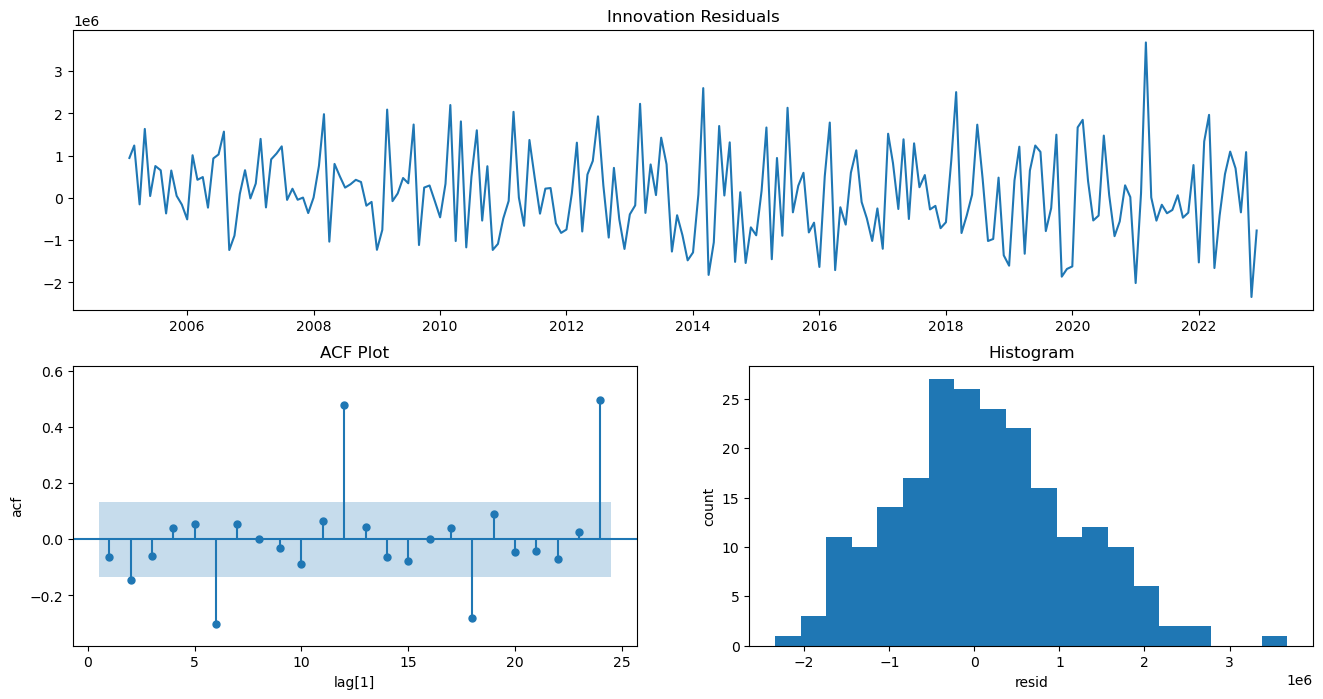

In [38]:
residuals = ra.residuals(data_diff, forecast_diff, order=1)

res = pd.DataFrame({
    'resid': residuals,
    'ds': st.index[1:],
    'unique_id': 'porto'
})

plot_diagnostics(res)

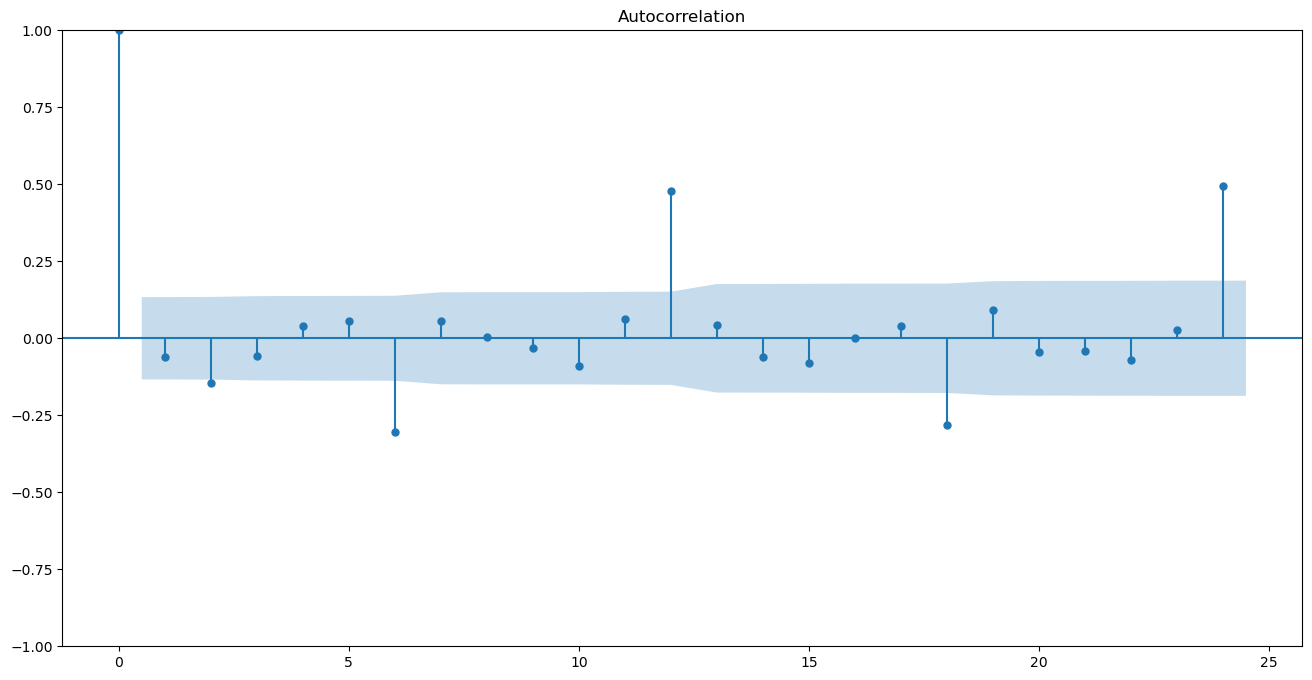

In [39]:
plot_acf(residuals, lags=24)
plt.show()

In [40]:
fts_lb = acorr_ljungbox(residuals, lags=[1, 6, 11, 12, 13, 24], return_df=True)
print(fts_lb.round(4))

     lb_stat  lb_pvalue
1     0.8230     0.3643
6    27.7391     0.0001
11   31.3794     0.0010
12   83.8451     0.0000
13   84.2864     0.0000
24  170.0339     0.0000


---

--- Performance Metrics (Sliding Window) ---
MAE:  1,321,618.91
RMSE: 1,835,155.84
MAPE: 9.05%


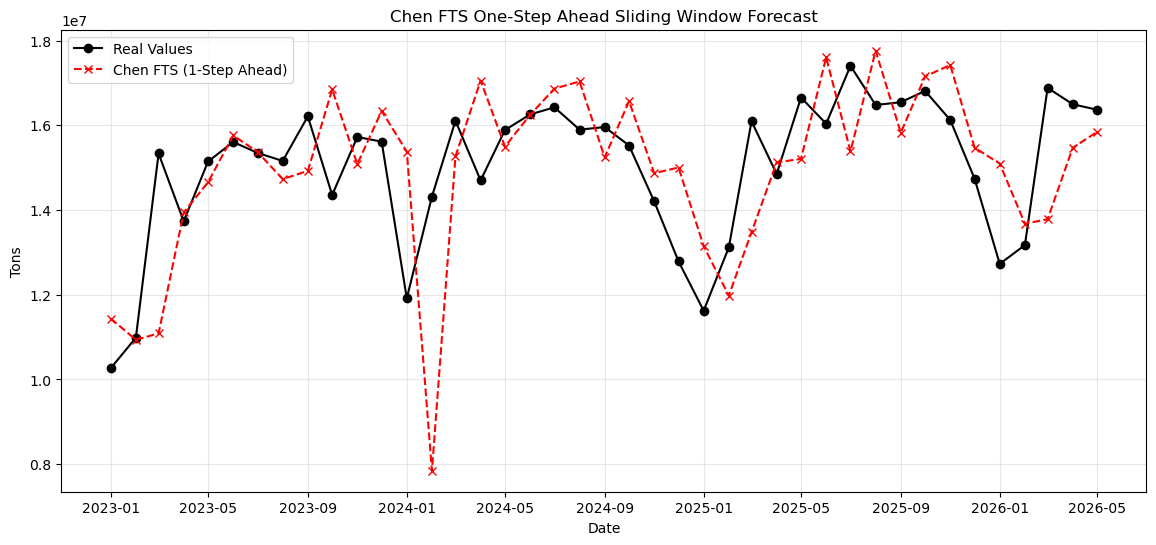

In [41]:
# Parameters
diff = Transformations.Differential(1)
real_values = real_st['porto'].values
train_data = st['porto'].values

forecasts = []

for t in range(len(real_values)):
    current_series = np.concatenate([train_data, real_values[:t]])

    # Skip zero-padding: real diffs start at index 1
    data_diff = np.array(diff.apply(current_series))[1:]

    part  = Grid.GridPartitioner(data=data_diff, npart=10)
    model = chen.ConventionalFTS(partitioner=part)
    model.fit(data_diff)

    # OOS prediction is the LAST element of the forecast list
    pred_diff_list = model.predict(data_diff, steps_ahead=1)
    pred_incremental = pred_diff_list[-1]   # ← was pred_diff_list[0]

    pred_final = current_series[-1] + pred_incremental
    forecasts.append(pred_final)

# Calculate Metrics
mae = mean_absolute_error(real_values, forecasts)
rmse = np.sqrt(mean_squared_error(real_values, forecasts))
mape = mean_absolute_percentage_error(real_values, forecasts) * 100

print(f"--- Performance Metrics (Sliding Window) ---")
print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")

# Visualization
plt.figure(figsize=(14, 6))
plt.plot(real_st.index, real_values, label='Real Values', color='black', marker='o')
plt.plot(real_st.index, forecasts, label='Chen FTS (1-Step Ahead)', color='red', linestyle='--', marker='x')
plt.title('Chen FTS One-Step Ahead Sliding Window Forecast')
plt.ylabel('Tons')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

# FTS de pesos probabilísticos e alta ordem — Previsão de 48 meses

O modelo PWFTS (Probabilistic Weighted FTS) estende o Chen em dois aspectos:

1. **Alta ordem**: considera $p$ lags anteriores $(t-1, t-2, \ldots, t-p)$, não apenas $t-1$
2. **Ponderação probabilística**: a defuzzificação é uma média ponderada sobre todos os RHS das FLRGs ativadas, proporcional ao grau de pertinência.

Para 48 passos usamos apenas `diff(12)` pois a inversão dupla recursiva acumula erro em duas cadeias simultâneas e colapsa no horizonte longo.

In [42]:
data = st['porto'].values

diff12 = Transformations.Differential(12)
data_d12 = diff12.apply(data)
data_d12 = np.array(data_d12[12:])
print(type(data_d12))
print(data_d12)

<class 'numpy.ndarray'>
[ -439531     5000   -46400   599651  -502476  -372724   -98617   816140
   710147   309821   356479  1170701  1287233   617350   825597   107552
   489963   606105   797752   -57512   633045   342208   634813  -759361
  -359239  -320021   264587   -89562   182420   400256   184258  -206702
   384081   423616   231801   875607  -361485  -357465  -248737   709702
   390638  -406923 -1063961   730432    23589   272319   370206   393939
  1163187  1112798  1220587   276258  1601334  1176162  1712599  1196251
  1318884  1824003   298681   231152   205991  -198238    20744  1048615
 -1041483   663435  1029662  -183788  -188202  -704560   -74809   375278
  -267845  1054283   704876   -96476   355870  -519172   161393  1285182
   887465  1364572  1460560  1081707  1820637   393858   933208  1372774
  1611738   803293   678551   723987   393067   412660    33555  -236646
 -1138001   261014  1012518  -720762 -1043940   590496  -397375  -639014
  -883261  -338971  -234170

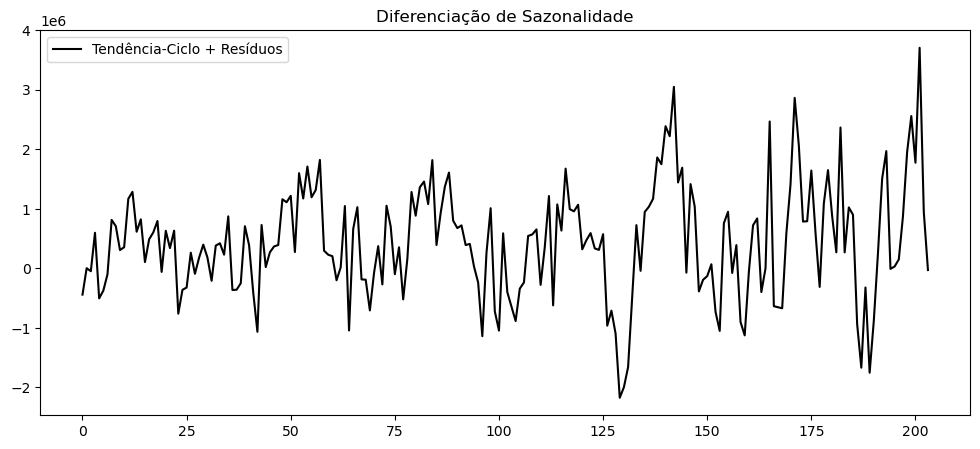

In [43]:
fig, ax = plt.subplots(figsize=[12,5])
ax.plot(data_d12, linewidth=1.5, label='Tendência-Ciclo + Resíduos', color='black')
ax.set_title('Diferenciação de Sazonalidade')
ax.legend()
plt.show()

Particionamento do UoD

/opt/conda/lib/python3.11/site-packages/pyFTS/partitioners/partitioner.py:238: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.xaxis.set_ticklabels(ticks)


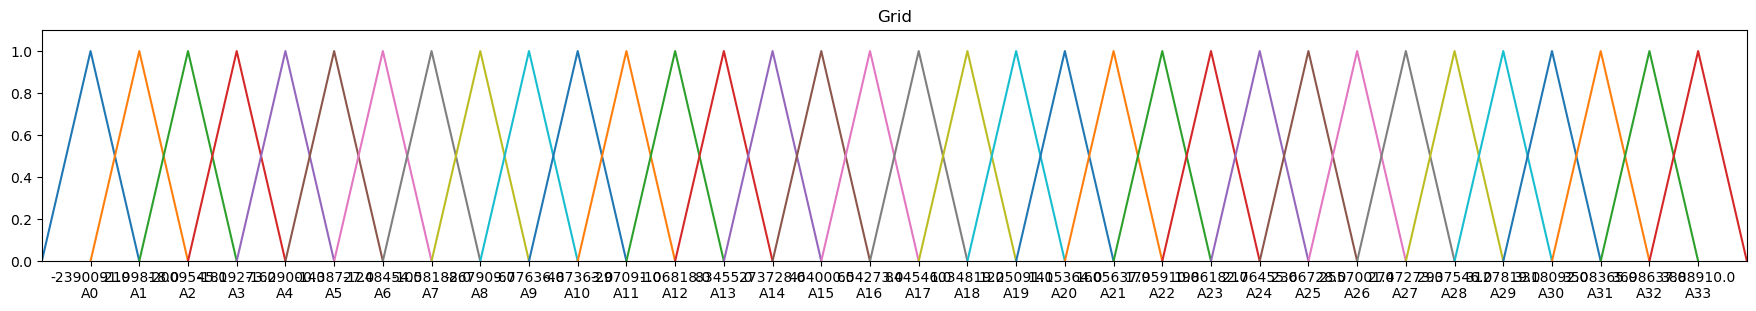

In [44]:
fig, ax = plt.subplots(figsize=[22,3])
pwfts_part = Grid.GridPartitioner(data=data_d12, npart=34)
pwfts_part.plot(ax)

atribuindo o modelo PWFTS aos nossos dados:

In [45]:
pwfts_model = pwfts.ProbabilisticWeightedFTS(partitioner=pwfts_part, order=3)
pwfts_model.fit(data_d12)
#print(pwfts_model)

In [46]:
print(len(pwfts_model))

1275


Gerando as previsões com base nas regras aprendidas:

In [47]:
pwfts_forecast = pwfts_model.predict(data_d12, steps_ahead=48)
print(pwfts_forecast)

[390074.6342635156, 166654.47181958356, 165119.20609397267, 109867.9002942407, 272077.2253540803, 357554.3051830642, 299909.0431443967, 389268.03737507935, 266171.34751005913, 456844.121728187, 35043.133377623555, -53791.142737153066, -442767.780967013, 20743.999999999964, 105799.80542790072, 320713.6628618493, 464511.0445362914, 432964.48102595913, 618710.3203059989, -181212.5222602093, 345364.14128322934, 336356.21823687805, 293481.910783483, 393966.78794411407, 261251.08319264627, 453319.2625075396, 27511.920514350055, -57111.0975974714, -434971.6200177752, 20743.999999999964, 66695.60359354998, 306037.51287831314, 556144.3586003977, 472717.4853302107, 582016.2709567535, -183422.0810877847, 284278.5170861784, 340912.18250227656, 265274.18184952403, 340774.71427526546, 239038.05327028062, 289152.6859096255, 250722.10576378237, 217659.1000357861, 149200.56412528807, 46223.305668692185, 88956.23597999138, 718616.112958939]


Aqui invertemos a diferenciação sazonal:

In [48]:
N = len(data)
forecast_original = []
for k in range(len(pwfts_forecast)):
    if k < 12:
        ref = data[N - 12 + k]
    else:
        ref = forecast_original[k - 12]
    forecast_original.append(pwfts_forecast[k] + ref)

undiff_data_pwfts = np.array(forecast_original)
print(undiff_data_pwfts)

[11090009.63426352 13066480.47181958 15323923.20609397 13902862.90029424
 14509531.22535408 14502343.30518306 14883627.0431444  15016058.03737508
 13894738.34751006 14892595.12172819 12229452.13337762 12042478.85726285
 10647241.8532965  13087224.47181958 15429723.01152187 14223576.56315609
 14974042.26989037 14935307.78620902 15502337.3634504  14834845.51511487
 14240102.48879329 15228951.33996507 12522934.04416111 12436445.64520696
 10908492.93648915 13540543.73432712 15457234.93203622 14166465.46555862
 14539070.6498726  14956051.78620902 15569032.96704395 15140883.02799318
 14796246.84739369 15701668.82529528 13104950.31511786 12253023.56411918
 11192771.45357533 13881455.9168294  15722509.11388575 14507240.17983389
 14778108.70314288 15245204.47211865 15819755.07280773 15358542.12802897
 14945447.41151897 15747892.13096397 13193906.55109785 12971639.67707811]


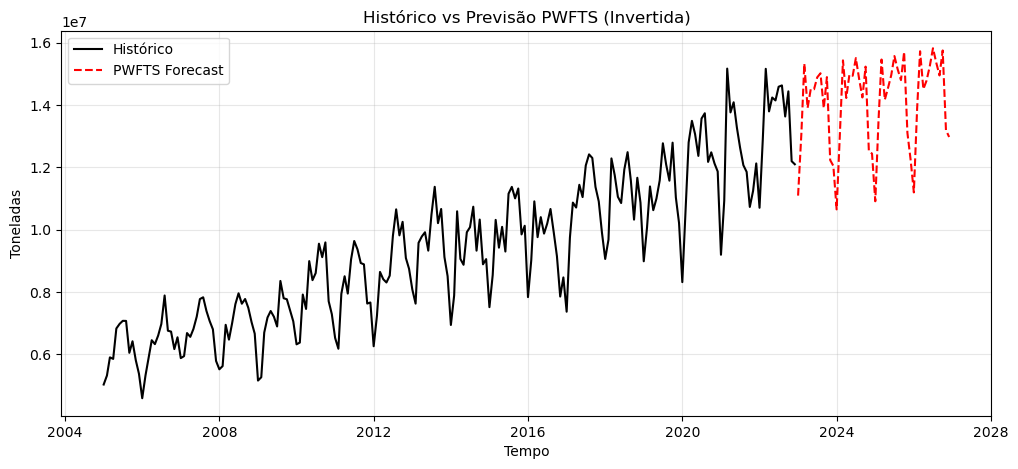

In [49]:
# Datas do histórico
hist_dates = st.index

# Datas da previsão (48 meses à frente)
forecast_dates = pd.date_range(
    start=hist_dates[-1] + pd.DateOffset(months=1),
    periods=len(undiff_data_pwfts),
    freq='MS'
)

fig, ax = plt.subplots(figsize=[12,5])

# Plot dados históricos
ax.plot(hist_dates, st['porto'], linewidth=1.5, color='black', label='Histórico')

# Plot PWFTS forecast
ax.plot(forecast_dates, undiff_data_pwfts, label='PWFTS Forecast', linewidth=1.5, color='red', linestyle='--')

ax.set_title('Histórico vs Previsão PWFTS (Invertida)')
ax.set_ylabel('Toneladas')
ax.set_xlabel('Tempo')
ax.legend()
plt.grid(True, alpha=0.3)
plt.show()

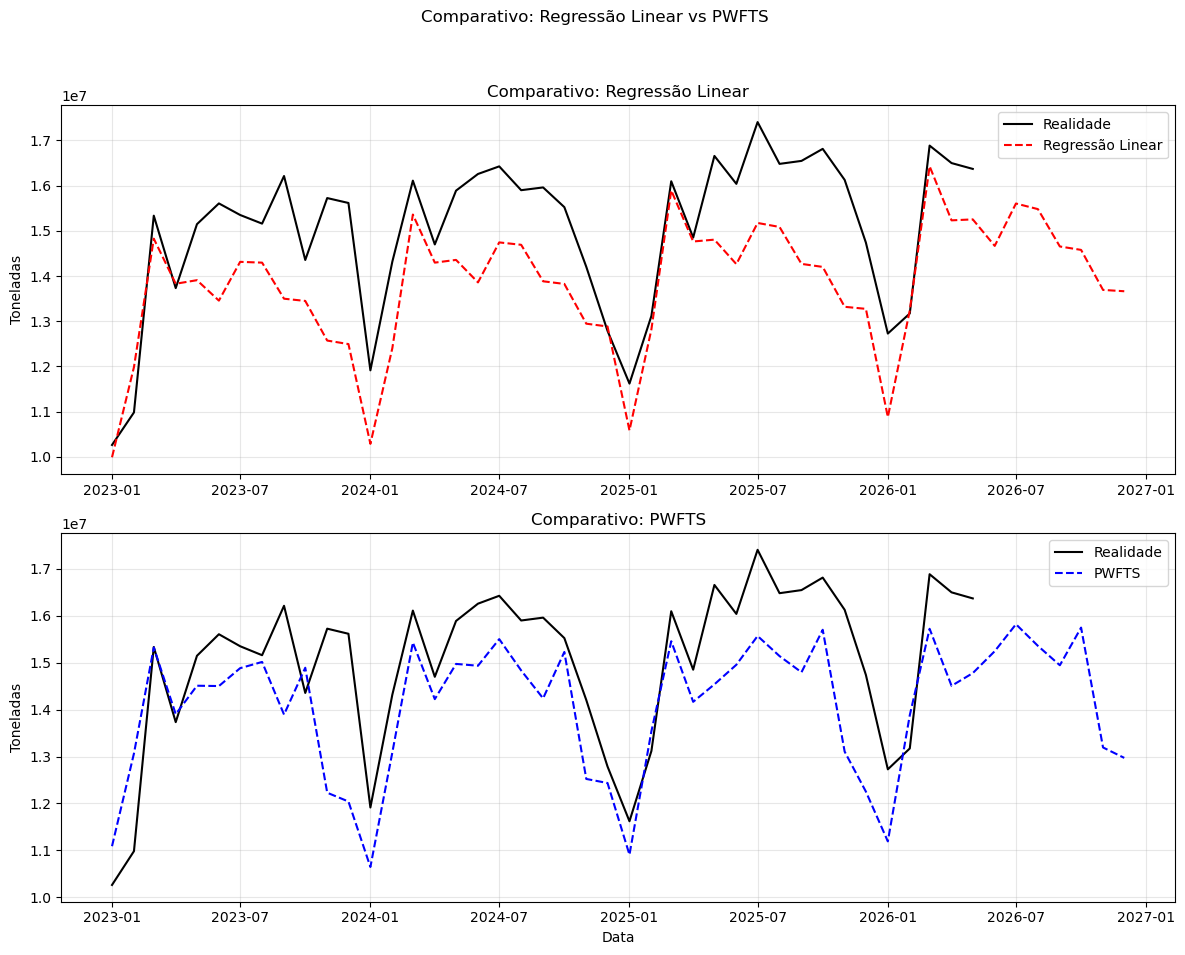

In [50]:
forecast_dates_pwfts = pd.date_range(
    start=real_st.index[0],
    periods=len(undiff_data_pwfts),
    freq='MS')
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Realidade vs Regressão Linear
ax[0].plot(real_st.index, real_st['porto'], color='black', linewidth=1.5, label='Realidade')
ax[0].plot(model_lin_reg.index, model_lin_reg['porto'], color='red', linewidth=1.5, linestyle='--', label='Regressão Linear')
ax[0].set_title('Comparativo: Regressão Linear')
ax[0].set_ylabel('Toneladas')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Plot 2: Realidade vs PWFTS
ax[1].plot(real_st.index, real_st['porto'], color='black', linewidth=1.5, label='Realidade')
ax[1].plot(forecast_dates_pwfts, undiff_data_pwfts, color='blue', linewidth=1.5, linestyle='--', label='PWFTS')
ax[1].set_title('Comparativo: PWFTS')
ax[1].set_xlabel('Data')
ax[1].set_ylabel('Toneladas')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

fig.suptitle('Comparativo: Regressão Linear vs PWFTS', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

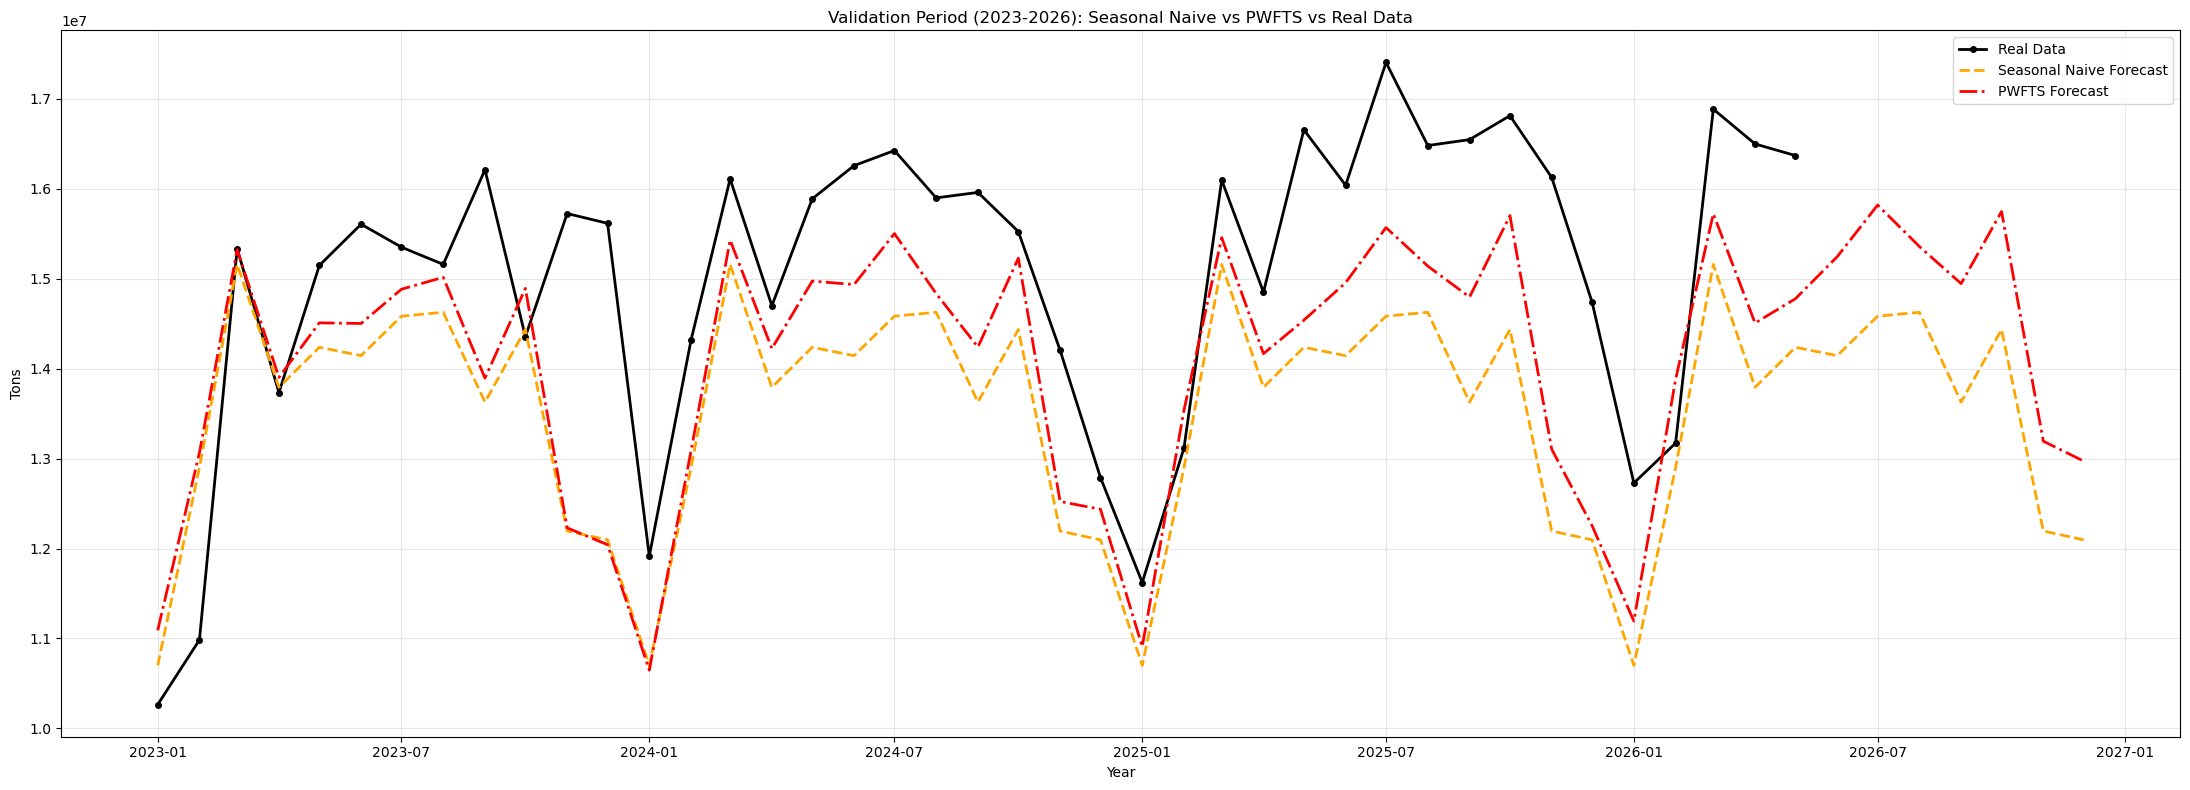

In [51]:
plt.figure(figsize=(22, 8))

plt.plot(real_st.index, real_st['porto'], label='Real Data', color='black', linewidth=2, marker='o', markersize=4)
plt.plot(forecast_seasonal_naive['ds'], forecast_seasonal_naive['y'], label='Seasonal Naive Forecast', color='orange', linestyle='--', linewidth=2)
plt.plot(forecast_dates_pwfts, undiff_data_pwfts, label='PWFTS Forecast', color='red', linestyle='-.', linewidth=2)

plt.title('Validation Period (2023-2026): Seasonal Naive vs PWFTS vs Real Data')
plt.xlabel('Year')
plt.ylabel('Tons')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [52]:
# 1. Prepare data (aligned to the 39 months available in real_st and forecasts)
y_true = real_st['porto'].values[:39]
y_pred_sn = forecast_seasonal_naive['y'].values[:39]
y_pred_pwfts = undiff_data_pwfts[:39]

# 2. Calculate Global Metrics
rmse_sn = np.sqrt(mean_squared_error(y_true, y_pred_sn))
mape_sn = mean_absolute_percentage_error(y_true, y_pred_sn) * 100

rmse_pwfts = np.sqrt(mean_squared_error(y_true, y_pred_pwfts))
mape_pwfts = mean_absolute_percentage_error(y_true, y_pred_pwfts) * 100

# 3. Calculate Percentage of Improvement (Aggregation over SN)
improvement_rmse = ((rmse_sn - rmse_pwfts) / rmse_sn) * 100
improvement_mape = ((mape_sn - mape_pwfts) / mape_sn) * 100

metrics_comp = pd.DataFrame({
    'Metric': ['RMSE', 'MAPE (%)'],
    'Seasonal Naive': [rmse_sn, mape_sn],
    'PWFTS': [rmse_pwfts, mape_pwfts],
    '% Improvement': [improvement_rmse, improvement_mape]
}).set_index('Metric')

print("Global Comparison (Validation Period):")
display(metrics_comp.round(2))

# 4. Point-by-Point Analysis
comparison_df = pd.DataFrame({
    'Date': real_st.index[:39],
    'Real': y_true,
    'SN_Pred': y_pred_sn,
    'PWFTS_Pred': y_pred_pwfts
})

comparison_df['SN_Error'] = np.abs(comparison_df['Real'] - comparison_df['SN_Pred'])
comparison_df['PWFTS_Error'] = np.abs(comparison_df['Real'] - comparison_df['PWFTS_Pred'])
comparison_df['PWFTS_Winner'] = comparison_df['PWFTS_Error'] < comparison_df['SN_Error']

print(f"\nPWFTS outperformed Seasonal Naive in {comparison_df['PWFTS_Winner'].sum()} out of {len(comparison_df)} months.")
print(f"Average MAPE Reduction: {improvement_mape:.2f}%")

Global Comparison (Validation Period):


,Seasonal Naive,PWFTS,% Improvement
Metric,,,
RMSE,1863004.11,1503526.16,19.30
MAPE (%),10.34,8.21,20.62



PWFTS outperformed Seasonal Naive in 31 out of 39 months.
Average MAPE Reduction: 20.62%


In [53]:
pwfts_res = pwfts_model.predict(data_d12, steps_ahead=1)
pwfts_residuals = ra.residuals(data_d12, pwfts_res, order=3)
print(pwfts_residuals)

[ 2.09576366e+05 -1.12637226e+05 -9.78060980e+04  7.00636176e+04
  1.40366195e+05  3.94564007e+04  1.20693858e+05 -9.73469527e+03
  5.13358502e+05  9.89647052e+04 -2.65780427e+05 -1.00805928e+03
 -6.52783202e+01 -1.89906336e+04  1.07441350e+05  7.49013800e+04
  3.29627587e+04  9.28552793e+04  5.27072361e+04  1.77283000e+05
 -2.00355204e+05  8.59398738e+04 -1.44187157e+04 -1.07558828e+05
  1.32700256e+03 -3.94519703e+03 -1.11552973e+05 -6.51832462e+04
 -4.16799770e+05  5.83280026e+05  6.48249475e+04 -9.37614139e+04
  3.78770997e+05 -6.69752344e+04 -1.56557068e+03  1.32658758e+04
  9.43367887e+04 -9.51296038e+04 -3.67762496e+05  0.00000000e+00
  0.00000000e+00  2.91038305e-11  1.16415322e-10  2.62138857e+05
  9.30160155e+04  7.07155703e+05 -4.28899718e+04  3.18071830e+05
 -3.59881547e+05  1.14135637e+05  3.50335323e+01  3.04797953e+02
  1.06649362e+05  8.27789079e+03  2.32830644e-10 -1.63892692e+05
 -8.22029552e+04  5.82076609e-11 -3.31513978e+05  1.24516386e+04
  2.66319142e+05 -1.14080

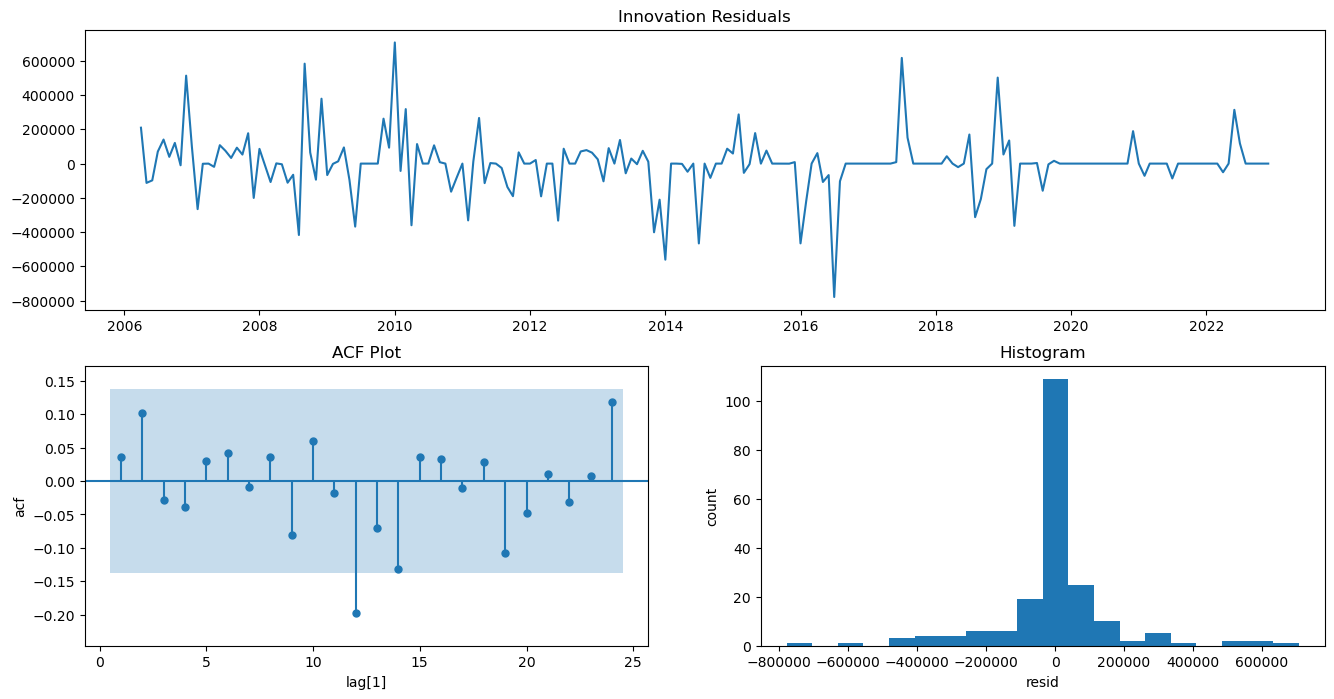

In [54]:
pwfts_analysis = pd.DataFrame({
    'resid': pwfts_residuals,
    'ds': st.index[15:],
    'unique_id': 'porto'
})

plot_diagnostics(pwfts_analysis)

In [55]:
pwfts_lb = acorr_ljungbox(pwfts_residuals, lags=[1, 6, 12, 13, 24], return_df=True)
print(pwfts_lb.round(4))

    lb_stat  lb_pvalue
1    0.2596     0.6104
6    3.4389     0.7521
12  14.3357     0.2798
13  15.3918     0.2835
24  26.4910     0.3287


---